In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted!")

Mounted at /content/drive
✅ Google Drive mounted!


##  Step 2: Set Your Data Path

Set `DATA_ROOT` to your **NPTEL** folder path in Google Drive.

Example: if you uploaded to `My Drive/NPTEL`, use:
```
DATA_ROOT = "/content/drive/MyDrive/NPTEL"
```

>  Keep the folder structure exactly as-is (the `data ` subfolder has a trailing space — do not rename it).

In [ ]:
# ✏️ EDIT THIS PATH
DATA_ROOT = "/content/drive/MyDrive/NPTEL"  # <-- change if needed

# ── Auto-resolve all sub-paths ───────────────────────────────────────────────
import os
from pathlib import Path

DATA_ROOT    = Path(DATA_ROOT)
DATA_DIR     = DATA_ROOT / "data"        # trailing space is intentional
PM25_DIR     = DATA_DIR / "PM_2.5"
PM10_DIR     = DATA_DIR / "PM10"
TEMP_DIR     = DATA_DIR / "TEMP"
HUMIDITY_DIR = DATA_DIR / "humidity"
NW_SHP_DIR   = DATA_ROOT / "NW_Himalayas_Shapefile"
INDIA_PM25   = DATA_DIR / "INDIA_PM25_data.csv"
MASKED_PM25  = PM25_DIR / "masked_pm25_data.csv"
OUTPUT_DIR   = DATA_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

checks = {
    "NPTEL Root":         DATA_ROOT,
    "data/ folder":       DATA_DIR,
    "PM2.5 folder":       PM25_DIR,
    "PM10 folder":        PM10_DIR,
    "Humidity folder":    HUMIDITY_DIR,
    "NW Shapefile dir":   NW_SHP_DIR,
    "INDIA_PM25_data.csv": INDIA_PM25,
    "masked_pm25_data.csv": MASKED_PM25,
}
all_ok = True
for name, path in checks.items():
    ok = path.exists()
    print(f"{'✅' if ok else '❌'} {name}: {path}")
    if not ok:
        all_ok = False
print("\n🎉 All paths found!" if all_ok else "\n⚠️  Some paths missing — check DATA_ROOT.")

✅ NPTEL Root: /content/drive/MyDrive/NPTEL
✅ data/ folder: /content/drive/MyDrive/NPTEL/data
✅ PM2.5 folder: /content/drive/MyDrive/NPTEL/data/PM_2.5
✅ PM10 folder: /content/drive/MyDrive/NPTEL/data/PM10
✅ Humidity folder: /content/drive/MyDrive/NPTEL/data/humidity
✅ NW Shapefile dir: /content/drive/MyDrive/NPTEL/NW_Himalayas_Shapefile
✅ INDIA_PM25_data.csv: /content/drive/MyDrive/NPTEL/data/INDIA_PM25_data.csv
✅ masked_pm25_data.csv: /content/drive/MyDrive/NPTEL/data/PM_2.5/masked_pm25_data.csv

🎉 All paths found!


##  Step 3: Install Dependencies

In [ ]:
!pip install -q geopandas fiona shapely pyproj
!pip install -q libpysal esda
!pip install -q seaborn scipy
print(" Packages ready!")

 Packages ready!


##  Step 4: Imports & Shared Setup

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
from pathlib import Path
from datetime import datetime
from scipy.interpolate import griddata, make_interp_spline
from shapely.geometry import Point
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.path import Path as MplPath
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    from libpysal.weights import KNN
    from esda.moran import Moran_Local
    SPATIAL_STATS = True
    print(" Spatial stats available")
except Exception:
    KNN = Moran_Local = None
    SPATIAL_STATS = False
    print("  libpysal/esda unavailable — Moran's I will be skipped")

plt.rcParams['figure.dpi'] = 100

# ── Shared helpers ────────────────────────────────────────────────────────────
def define_season(month):
    if month in (10,11,12,1): return "Winter"
    if month in (2,3,4,5):   return "Summer"
    return "Monsoon"

# ── Load NW Himalayas shapefile ───────────────────────────────────────────────
NW_SHAPEFILE_OPTIONS = [
    "Himalayan_NW_Region.shp",
    "Core_NW_Himalayas.shp",
    "NW_Himalayas_Boundary.shp",
    "NW_Himalayas_States.shp",
]
nw_gdf = None
nw_boundary = None
for shp_name in NW_SHAPEFILE_OPTIONS:
    p = NW_SHP_DIR / shp_name
    if p.exists():
        try:
            nw_gdf = gpd.read_file(p)
            nw_boundary = nw_gdf.dissolve().geometry.iloc[0] if shp_name == "NW_Himalayas_States.shp" else nw_gdf.geometry.iloc[0]
            print(f" Loaded shapefile: {shp_name}")
            break
        except Exception as e:
            print(f"  {shp_name}: {e}")

print(" Setup complete!")

 Spatial stats available
 Loaded shapefile: Himalayan_NW_Region.shp
 Setup complete!


---
##  Plot 1: Annual PM2.5 Boxplot (2010–2024)

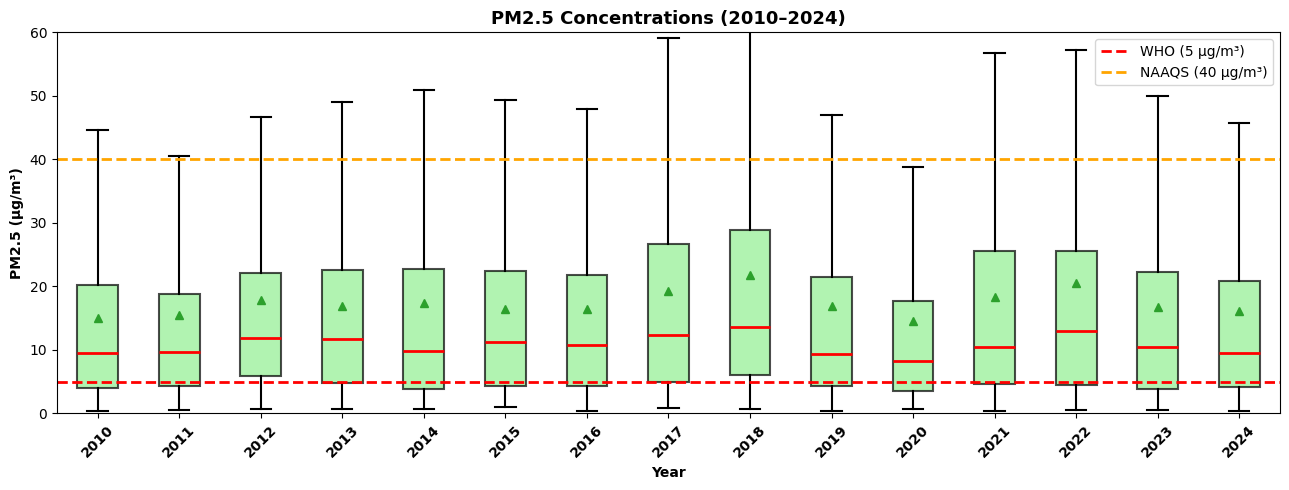

 Saved: /content/drive/MyDrive/NPTEL/outputs/Fig_Annual_Boxplot_PM25.png


In [ ]:
years, all_data = [], []
for year in range(2010, 2025):
    fp = PM25_DIR / f"{year}_data.csv"
    if not fp.exists(): continue
    df = pd.read_csv(fp)
    cols = [c for c in df.columns if c not in ["lat","lon"]]
    vals = np.concatenate([df[c].dropna().to_numpy(float)*1e9 for c in cols]).tolist()
    if vals:
        years.append(year); all_data.append(vals)

fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot(all_data, labels=years, showmeans=True, showfliers=False, patch_artist=True)
for b in bp["boxes"]:   b.set(facecolor="lightgreen", alpha=0.7, linewidth=1.5)
for w in bp["whiskers"]: w.set(linewidth=1.5, color="black")
for c in bp["caps"]:    c.set(linewidth=1.5, color="black")
for m in bp["medians"]: m.set(linewidth=2, color="red")
ax.axhline(5,  color="red",    linestyle="--", linewidth=2, label="WHO (5 µg/m³)")
ax.axhline(40, color="orange", linestyle="--", linewidth=2, label="NAAQS (40 µg/m³)")
ax.set_xlabel("Year", fontweight="bold"); ax.set_ylabel("PM2.5 (µg/m³)", fontweight="bold")
ax.set_title("PM2.5 Concentrations (2010–2024)", fontweight="bold", fontsize=13)
ax.set_ylim(0, 60); plt.xticks(rotation=45, fontweight="bold"); ax.legend()
plt.tight_layout()
out = OUTPUT_DIR / "Fig_Annual_Boxplot_PM25.png"
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f" Saved: {out}")

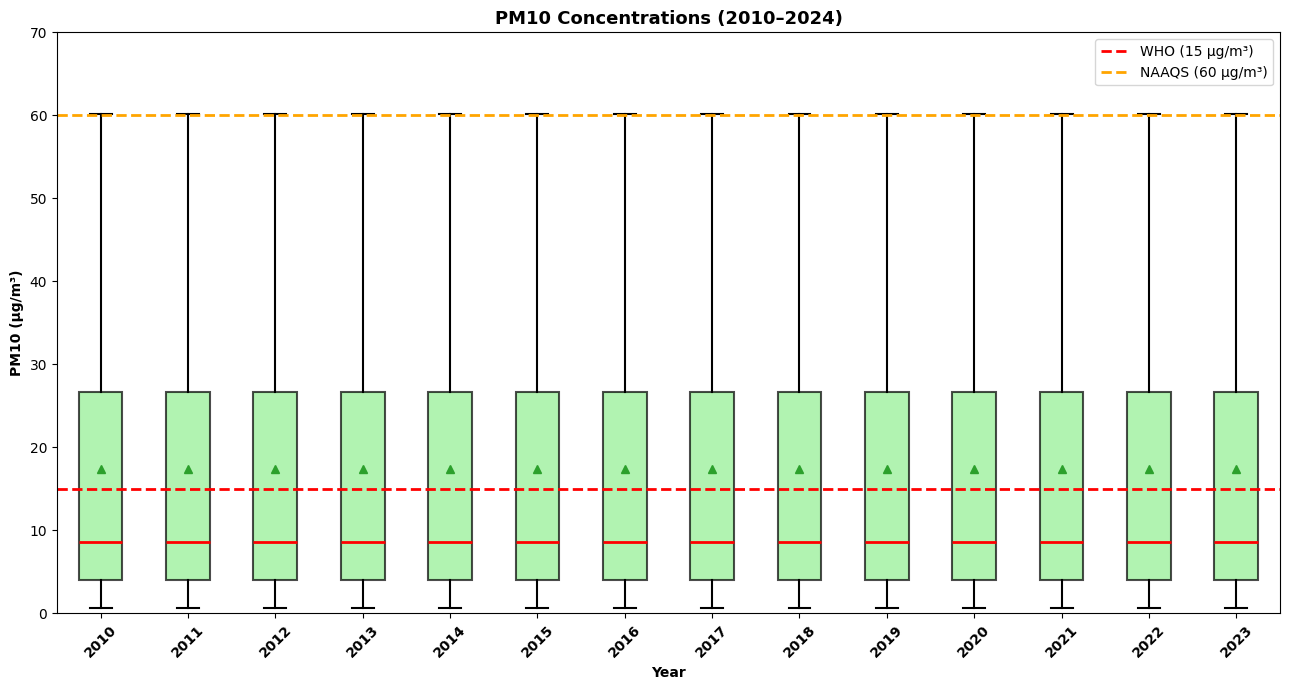

 Saved: /content/drive/MyDrive/NPTEL/outputs/Fig_Annual_Boxplot_PM10.png


In [ ]:
years, all_data = [], []
for year in range(2010, 2025):
    fp = PM10_DIR / f"{year}_data.csv"
    if not fp.exists(): continue
    df = pd.read_csv(fp)
    cols = [c for c in df.columns if c not in ["lat","lon"]]
    vals = np.concatenate([df[c].dropna().to_numpy(float) for c in cols]).tolist()
    if vals:
        years.append(year); all_data.append(vals)

fig, ax = plt.subplots(figsize=(13, 7))
bp = ax.boxplot(all_data, labels=years, showmeans=True, showfliers=False, patch_artist=True)
for b in bp["boxes"]:   b.set(facecolor="lightgreen", alpha=0.7, linewidth=1.5)
for w in bp["whiskers"]: w.set(linewidth=1.5, color="black")
for c in bp["caps"]:    c.set(linewidth=1.5, color="black")
for m in bp["medians"]: m.set(linewidth=2, color="red")
ax.axhline(15,  color="red",    linestyle="--", linewidth=2, label="WHO (15 µg/m³)")
ax.axhline(60, color="orange", linestyle="--", linewidth=2, label="NAAQS (60 µg/m³)")
ax.set_xlabel("Year", fontweight="bold"); ax.set_ylabel("PM10 (µg/m³)", fontweight="bold")
ax.set_title("PM10 Concentrations (2010–2024)", fontweight="bold", fontsize=13)
ax.set_ylim(0, 70); plt.xticks(rotation=45, fontweight="bold"); ax.legend()
plt.tight_layout()
out = OUTPUT_DIR / "Fig_Annual_Boxplot_PM10.png"
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f" Saved: {out}")

---
##  Plot 2: Monthly PM2.5 Boxplot

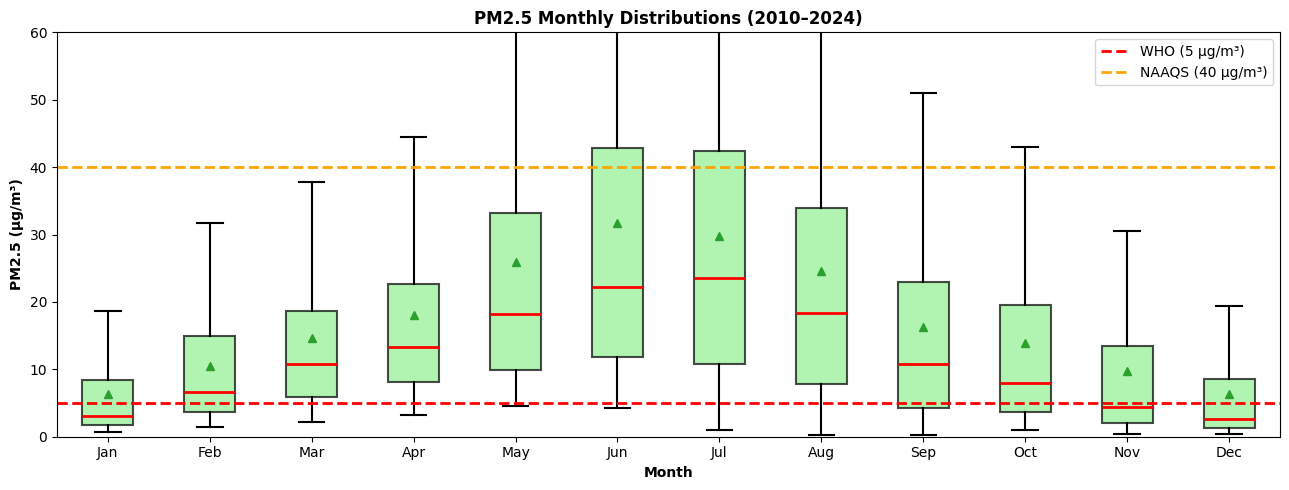

✅ Saved: /content/drive/MyDrive/NPTEL/outputs/Fig_Monthly_Boxplot_PM25.png


In [ ]:
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = {m: [] for m in range(1,13)}
for year in range(2010, 2025):
    fp = PM25_DIR / f"{year}_data.csv"
    if not fp.exists(): continue
    df = pd.read_csv(fp)
    for col in [c for c in df.columns if c not in ["lat","lon"]]:
        try:
            sep = "-" if "-" in col else "_"
            m = int(col.split(sep)[1])
            vals = df[col].dropna().to_numpy(float) * 1e9
            if vals.size: monthly[m].extend(vals.tolist())
        except: pass

fig, ax = plt.subplots(figsize=(13, 5))
bp = ax.boxplot([monthly[m] for m in range(1,13)], labels=MONTH_LABELS,
                showmeans=True, showfliers=False, patch_artist=True)
for b in bp["boxes"]:   b.set(facecolor="lightgreen", alpha=0.7, linewidth=1.5)
for w in bp["whiskers"]: w.set(linewidth=1.5, color="black")
for c in bp["caps"]:    c.set(linewidth=1.5, color="black")
for m in bp["medians"]: m.set(linewidth=2, color="red")
ax.axhline(5,  color="red",    linestyle="--", linewidth=2, label="WHO (5 µg/m³)")
ax.axhline(40, color="orange", linestyle="--", linewidth=2, label="NAAQS (40 µg/m³)")
ax.set_xlabel("Month", fontweight="bold"); ax.set_ylabel("PM2.5 (µg/m³)", fontweight="bold")
ax.set_title("PM2.5 Monthly Distributions (2010–2024)", fontweight="bold", fontsize=12)
ax.set_ylim(0, 60); ax.legend()
plt.tight_layout()
out = OUTPUT_DIR / "Fig_Monthly_Boxplot_PM25.png"
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f" Saved: {out}")

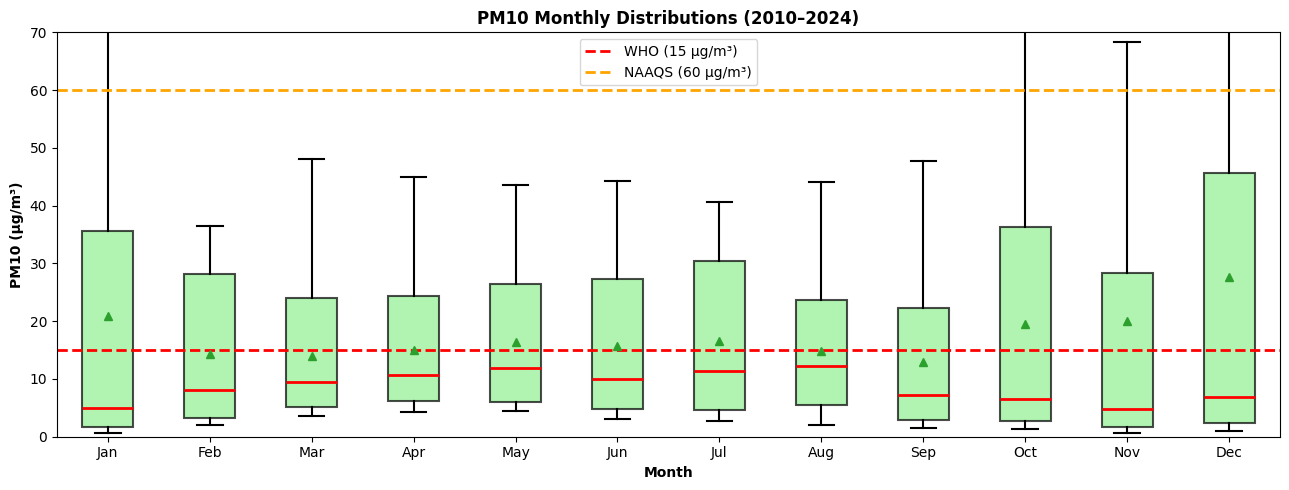

 Saved: /content/drive/MyDrive/NPTEL/outputs/Fig_Monthly_Boxplot_PM10.png


In [ ]:
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = {m: [] for m in range(1,13)}
for year in range(2010, 2025):
    fp = PM10_DIR / f"{year}_data.csv"
    if not fp.exists(): continue
    df = pd.read_csv(fp)
    for col in [c for c in df.columns if c not in ["lat","lon"]]:
        try:
            sep = "-" if "-" in col else "_"
            m = int(col.split(sep)[1])
            vals = df[col].dropna().to_numpy(float)
            if vals.size: monthly[m].extend(vals.tolist())
        except: pass

fig, ax = plt.subplots(figsize=(13, 5))
bp = ax.boxplot([monthly[m] for m in range(1,13)], labels=MONTH_LABELS,
                showmeans=True, showfliers=False, patch_artist=True)
for b in bp["boxes"]:   b.set(facecolor="lightgreen", alpha=0.7, linewidth=1.5)
for w in bp["whiskers"]: w.set(linewidth=1.5, color="black")
for c in bp["caps"]:    c.set(linewidth=1.5, color="black")
for m in bp["medians"]: m.set(linewidth=2, color="red")
ax.axhline(15,  color="red",    linestyle="--", linewidth=2, label="WHO (15 µg/m³)")
ax.axhline(60, color="orange", linestyle="--", linewidth=2, label="NAAQS (60 µg/m³)")
ax.set_xlabel("Month", fontweight="bold"); ax.set_ylabel("PM10 (µg/m³)", fontweight="bold")
ax.set_title("PM10 Monthly Distributions (2010–2024)", fontweight="bold", fontsize=12)
ax.set_ylim(0, 70); ax.legend()
plt.tight_layout()
out = OUTPUT_DIR / "Fig_Monthly_Boxplot_PM10.png"
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print(f" Saved: {out}")


##  Plots 3 & 4: Seasonal Time Series (Winter & Monsoon)

In [ ]:
REGIONS = {"Ladakh":(34.0,78.0), "Mandi":(31.7,76.9), "Punjab":(31.0,75.5), "Delhi":(28.6,77.2)}
STYLES  = {
    "Ladakh": {"color":"#3498db","marker":"o","mcolor":"#2980b9"},
    "Mandi":  {"color":"#e67e22","marker":"s","mcolor":"#d35400"},
    "Punjab": {"color":"#27ae60","marker":"^","mcolor":"#229954"},
    "Delhi":  {"color":"#e74c3c","marker":"D","mcolor":"#c0392b"},
}

india_df = pd.read_csv(INDIA_PM25)

def find_nearest(df, lat, lon):
    d = np.sqrt((df["lat"]-lat)**2 + (df["lon"]-lon)**2)
    return int(d.idxmin())

def extract_ts(df, idx):
    parsed = []
    for col in [c for c in df.columns if c not in ["lat","lon"]]:
        sep = "-" if "-" in col else "_"
        p = col.split(sep)
        if len(p) < 2: continue
        try: parsed.append((datetime(int(p[0]),int(p[1]),1), col))
        except: continue
    parsed.sort(key=lambda x: x[0])
    dates = [d for d,_ in parsed]
    vals  = df.loc[idx,[c for _,c in parsed]].to_numpy(float) * 1e9
    return dates, vals

def filter_months(dates, vals, months):
    kd, kv = [], []
    for d,v in zip(dates, vals):
        if d.month in months and np.isfinite(v):
            kd.append(d); kv.append(float(v))
    return kd, np.array(kv)

def plot_ts(ts, title, out_path):
    fig, ax = plt.subplots(figsize=(12, 7), facecolor="white")
    ax.set_facecolor("white")
    for region, (dates, vals) in ts.items():
        st = STYLES[region]
        if not dates: continue
        dn = mdates.date2num(dates)
        if len(dn) > 3:
            xs = np.linspace(dn.min(), dn.max(), 200)
            ax.plot(xs, make_interp_spline(dn, vals, k=3)(xs),
                    color=st["color"], linewidth=3, label=region)
        else:
            ax.plot(dates, vals, color=st["color"], linewidth=3, label=region)
        ax.scatter(dates, vals, color=st["mcolor"], marker=st["marker"],
                   s=60, edgecolors="white", linewidths=1.5, zorder=5)
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel("Year", fontsize=12, fontweight="bold")
    ax.set_ylabel("PM2.5 (µg/m³)", fontsize=12, fontweight="bold")
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=45); ax.grid(True, alpha=0.2, linestyle="--")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show(); print(f" Saved: {out_path}")

print(" Time series helpers ready — run next cells to plot")

✅ Time series helpers ready — run next cells to plot


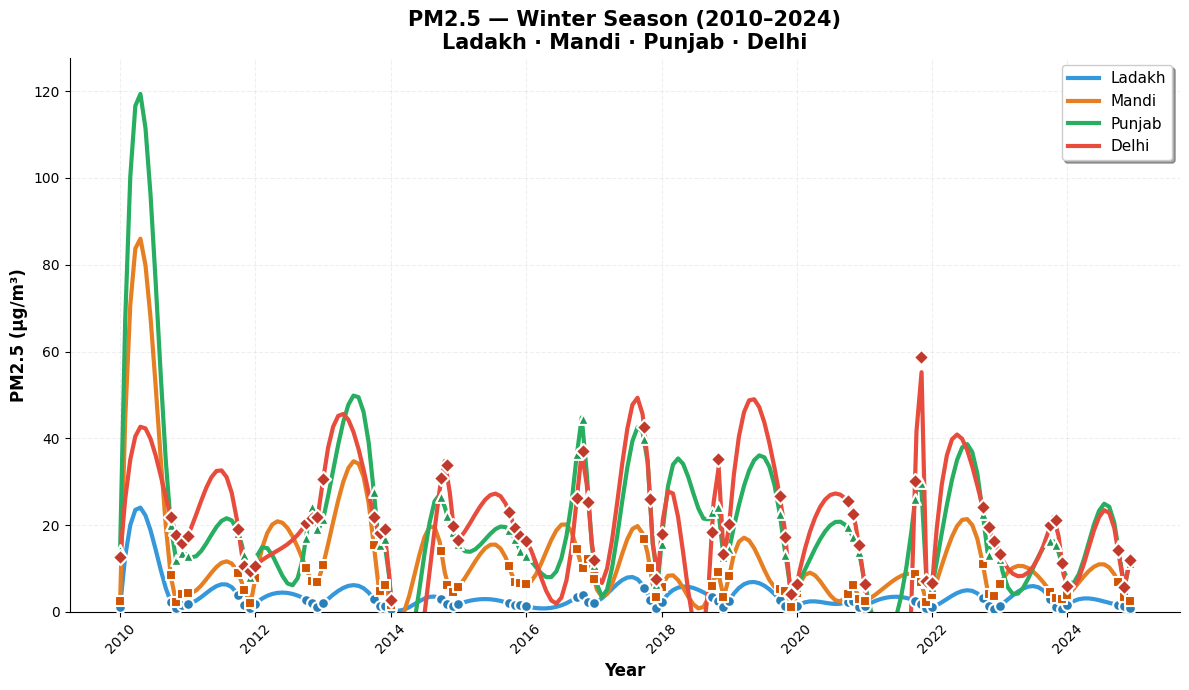

✅ Saved: /content/drive/MyDrive/NPTEL/outputs/pm25_winter_season_timeseries.png


In [ ]:
# Winter
ts = {}
for name,(lat,lon) in REGIONS.items():
    idx = find_nearest(india_df, lat, lon)
    dates, vals = extract_ts(india_df, idx)
    ts[name] = filter_months(dates, vals, [10,11,12,1])
plot_ts(ts, "PM2.5 — Winter Season (2010–2024)\nLadakh · Mandi · Punjab · Delhi",
        OUTPUT_DIR / "pm25_winter_season_timeseries.png")

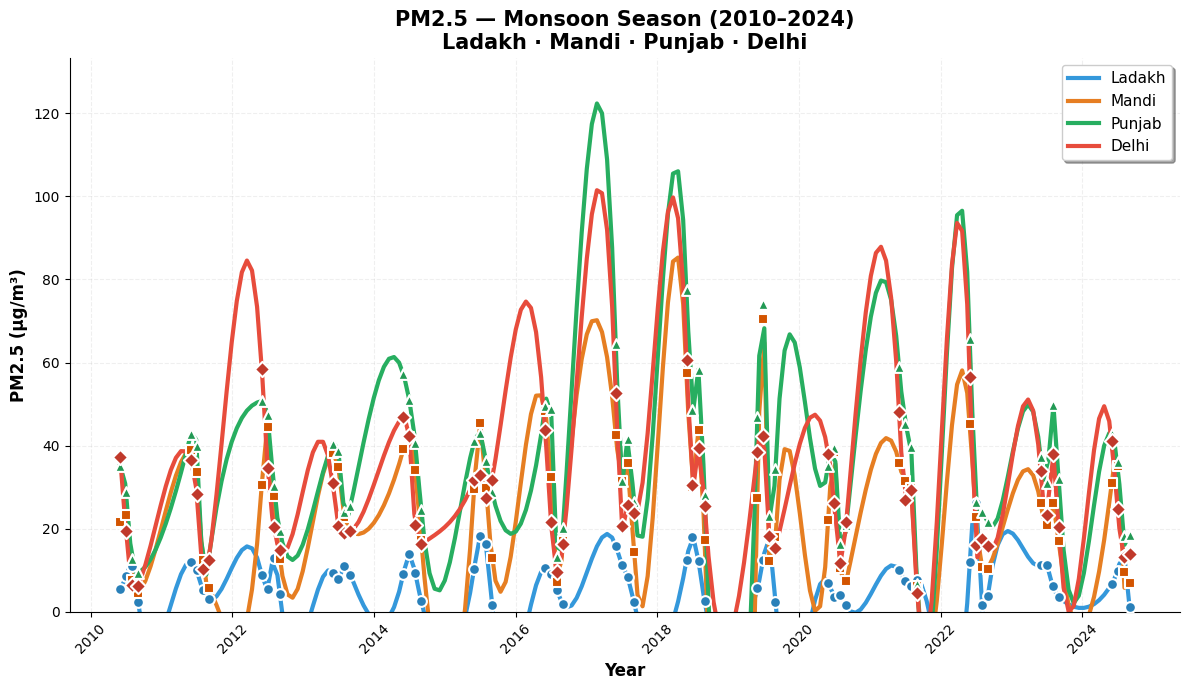

✅ Saved: /content/drive/MyDrive/NPTEL/outputs/pm25_monsoon_season_timeseries.png


In [ ]:
# Monsoon
ts = {}
for name,(lat,lon) in REGIONS.items():
    idx = find_nearest(india_df, lat, lon)
    dates, vals = extract_ts(india_df, idx)
    ts[name] = filter_months(dates, vals, [6,7,8,9])
plot_ts(ts, "PM2.5 — Monsoon Season (2010–2024)\nLadakh · Mandi · Punjab · Delhi",
        OUTPUT_DIR / "pm25_monsoon_season_timeseries.png")

---
##  Plots 5 & 6: Seasonal Spatial Maps — PM2.5 & PM10

In [ ]:
def load_gridded(data_dir, mult):
    dfs = []
    for fp in sorted(data_dir.glob("20??_data.csv")):
        year = int(fp.stem.split("_")[0])
        df   = pd.read_csv(fp)
        vv   = [c for c in df.columns if c.startswith(f"{year}-")]
        dl   = pd.melt(df, id_vars=["lat","lon"], value_vars=vv, var_name="date", value_name="value")
        dl["value"]  = dl["value"].astype(float) * mult
        dl["month"]  = dl["date"].str.split("-").str[1].astype(int)
        dl["season"] = dl["month"].map(define_season)
        dfs.append(dl.dropna(subset=["value"]))
    return pd.concat(dfs, ignore_index=True) if dfs else None

def seasonal_means(df):
    return df.groupby(["lat","lon","season"], as_index=False)["value"].mean().dropna()

def plot_spatial(means, gdf, title, unit, cmap, vmax, out_path):
    seasons = ["Winter","Summer","Monsoon"]; labels = ["ONDJ","FMAM","JJAS"]
    fig, axes = plt.subplots(1, 3, figsize=(22, 8), facecolor="white", gridspec_kw={"wspace":0.35})
    fig.suptitle(title, fontsize=18, fontweight="bold", y=0.98)
    for ax, s, lbl in zip(axes, seasons, labels):
        sd = means[means["season"]==s]
        ax.set_title(f"{s} ({lbl})", fontsize=14, fontweight="bold")
        if sd.empty: continue
        sc = ax.scatter(sd["lon"], sd["lat"], c=sd["value"], cmap=cmap,
                        vmin=0, vmax=vmax, s=18, marker="s",
                        edgecolors="black", linewidths=0.15, alpha=0.95, zorder=3)
        if gdf is not None:
            try: gdf.boundary.plot(ax=ax, color="black", linewidth=1.2, alpha=0.9, zorder=5)
            except: pass
        ax.set_xlabel("Longitude", fontsize=11, fontweight="bold")
        ax.set_ylabel("Latitude",  fontsize=11, fontweight="bold")
        ax.grid(True, linestyle="--", alpha=0.25)
        ax.set_xlim(sd["lon"].min()-0.3, sd["lon"].max()+0.3)
        ax.set_ylim(sd["lat"].min()-0.3, sd["lat"].max()+0.3)
        cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(unit, fontsize=10, fontweight="bold")
    plt.tight_layout(rect=[0,0.03,1,0.93])
    plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show(); print(f"Saved: {out_path}")

print(" Spatial map helpers ready")

✅ Spatial map helpers ready


In [ ]:
print("Loading PM2.5...")
pm25_df = load_gridded(PM25_DIR, 1e9)
pm25_m  = seasonal_means(pm25_df)


Loading PM2.5...


---
##  Plot 7: PM2.5 Stacked Seasons — Fixed Scale (Western Himalayas)

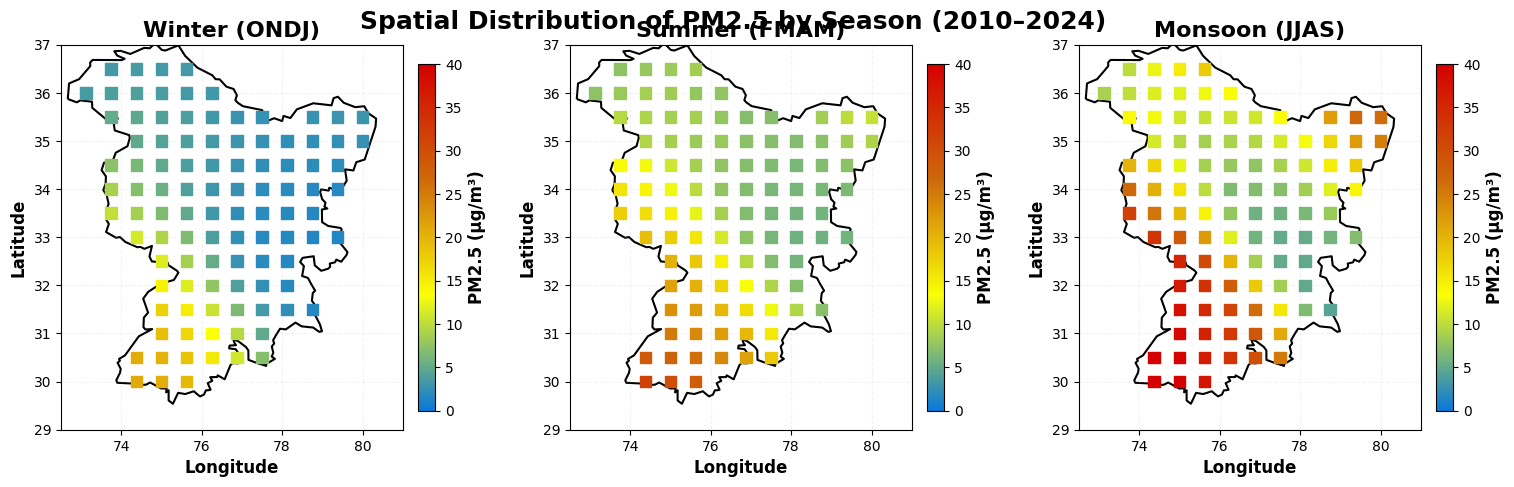

✅ Saved: /content/drive/MyDrive/NPTEL/outputs/PM25_seasons_stacked_fixed_scale.png


In [ ]:
WH = dict(min_lat=29.0, max_lat=37.0, min_lon=72.5, max_lon=81.0)
CBAR_MAX = 40.0
COLORS   = ["#0878DA","#FBFF07","#CE690A","#D50000"]
cmap_c   = LinearSegmentedColormap.from_list("custom", COLORS, N=256)
norm_c   = plt.Normalize(0, CBAR_MAX)

wh = pm25_df[(pm25_df.lon>=WH["min_lon"])&(pm25_df.lon<=WH["max_lon"])&
             (pm25_df.lat>=WH["min_lat"])&(pm25_df.lat<=WH["max_lat"])].copy()
if nw_boundary is not None and not wh.empty:
    geom = gpd.GeoSeries([Point(x,y) for x,y in zip(wh.lon, wh.lat)])
    wh   = wh[geom.within(nw_boundary).values].copy()

seasons = ["Winter","Summer","Monsoon"]; labels = ["ONDJ","FMAM","JJAS"]
fig, axes = plt.subplots(1, 3, figsize=(18,5), facecolor="white", gridspec_kw={"wspace":0.35})
fig.suptitle("Spatial Distribution of PM2.5 by Season (2010–2024)", fontsize=18, fontweight="bold", y=0.95)
for ax, s, lbl in zip(axes, seasons, labels):
    ax.set_facecolor("white")
    lm = wh[wh.season==s].groupby(["lat","lon"], as_index=False)["value"].mean()
    ax.set_title(f"{s} ({lbl})", fontsize=16, fontweight="bold")
    if lm.empty: continue
    if nw_gdf is not None:
        try: nw_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=1)
        except: pass
    c = cmap_c(norm_c(lm.value.to_numpy(float)))
    ax.scatter(lm.lon, lm.lat, c=c, alpha=1, s=70, marker="s", zorder=5)
    sm = plt.cm.ScalarMappable(norm=norm_c, cmap=cmap_c); sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("PM2.5 (µg/m³)", fontsize=12, fontweight="bold")
    ax.set_xlim(WH["min_lon"], WH["max_lon"]); ax.set_ylim(WH["min_lat"], WH["max_lat"])
    ax.set_xlabel("Longitude", fontsize=12, fontweight="bold")
    ax.set_ylabel("Latitude",  fontsize=12, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.15)
plt.tight_layout(rect=[0,0.03,1,0.92])
out = OUTPUT_DIR / "PM25_seasons_stacked_fixed_scale.png"
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white"); plt.show()
print(f" Saved: {out}")

In [ ]:
print("Loading PM10...")
pm10_df = load_gridded(PM10_DIR, 1.0)
pm10_m  = seasonal_means(pm10_df)


Loading PM10...


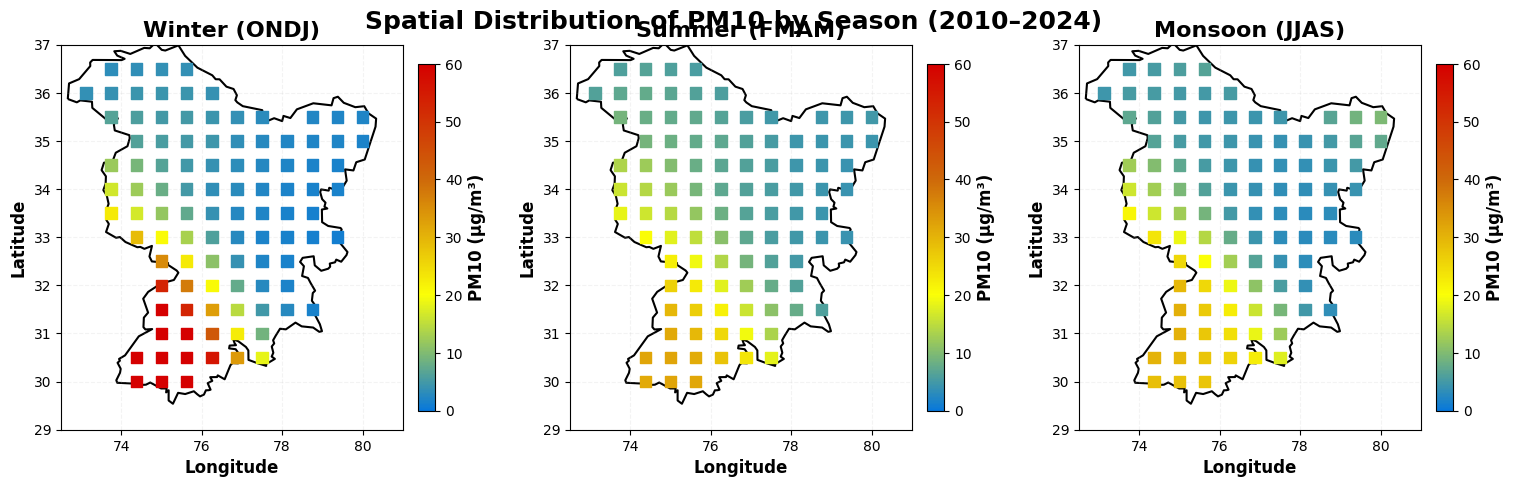

✅ Saved: /content/drive/MyDrive/NPTEL/outputs/PM10_seasons_stacked_fixed_scale.png


In [ ]:
WH = dict(min_lat=29.0, max_lat=37.0, min_lon=72.5, max_lon=81.0)
CBAR_MAX = 60.0
COLORS   = ["#0878DA","#FBFF07","#CE690A","#D50000"]
cmap_c   = LinearSegmentedColormap.from_list("custom", COLORS, N=256)
norm_c   = plt.Normalize(0, CBAR_MAX)

wh = pm10_df[(pm10_df.lon>=WH["min_lon"])&(pm10_df.lon<=WH["max_lon"])&
             (pm10_df.lat>=WH["min_lat"])&(pm10_df.lat<=WH["max_lat"])].copy()
if nw_boundary is not None and not wh.empty:
    geom = gpd.GeoSeries([Point(x,y) for x,y in zip(wh.lon, wh.lat)])
    wh   = wh[geom.within(nw_boundary).values].copy()

seasons = ["Winter","Summer","Monsoon"]; labels = ["ONDJ","FMAM","JJAS"]
fig, axes = plt.subplots(1, 3, figsize=(18,5), facecolor="white", gridspec_kw={"wspace":0.35})
fig.suptitle("Spatial Distribution of PM10 by Season (2010–2024)", fontsize=18, fontweight="bold", y=0.95)
for ax, s, lbl in zip(axes, seasons, labels):
    ax.set_facecolor("white")
    lm = wh[wh.season==s].groupby(["lat","lon"], as_index=False)["value"].mean()
    ax.set_title(f"{s} ({lbl})", fontsize=16, fontweight="bold")
    if lm.empty: continue
    if nw_gdf is not None:
        try: nw_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=1)
        except: pass
    c = cmap_c(norm_c(lm.value.to_numpy(float)))
    ax.scatter(lm.lon, lm.lat, c=c, alpha=1, s=70, marker="s", zorder=5)
    sm = plt.cm.ScalarMappable(norm=norm_c, cmap=cmap_c); sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("PM10 (µg/m³)", fontsize=12, fontweight="bold")
    ax.set_xlim(WH["min_lon"], WH["max_lon"]); ax.set_ylim(WH["min_lat"], WH["max_lat"])
    ax.set_xlabel("Longitude", fontsize=12, fontweight="bold")
    ax.set_ylabel("Latitude",  fontsize=12, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.15)
plt.tight_layout(rect=[0,0.03,1,0.92])
out = OUTPUT_DIR / "PM10_seasons_stacked_fixed_scale.png"
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white"); plt.show()
print(f" Saved: {out}")

---
##  Plot 8: PM2.5 + Humidity Gradient (3-Panel)

In [ ]:
def load_climatology(folder):
    pats = ["????.csv","20??.csv","20??_data.csv","*_data.csv","*_hdata.csv"]
    files = set()
    for p in pats: files.update(folder.glob(p))
    dfs = []
    for f in sorted(files):
        try:
            df = pd.read_csv(f)
            if {"lat","lon"}.issubset(df.columns): dfs.append(df)
        except: pass
    if not dfs: return None
    combined = pd.concat(dfs, ignore_index=True)
    mcols = [c for c in combined.columns if "-" in c and len(c.split("-"))==2]
    return combined.groupby(["lat","lon"], as_index=False)[mcols].mean() if mcols else None

def s_mnths(season):
    return {"Winter":["10","11","12","01"],"Summer":["02","03","04","05"],"Monsoon":["06","07","08","09"]}[season]

def pm25_seas(clim, season):
    cols = [c for c in clim.columns if "-" in c and c.split("-")[1] in s_mnths(season)]
    if not cols: return None
    out = clim[["lat","lon"]].copy(); out["pm25"] = clim[cols].mean(axis=1)*1e9; return out

def hum_seas(clim, season):
    cols = [c for c in clim.columns if "-" in c and c.split("-")[1] in s_mnths(season)]
    if not cols: return None
    out = clim[["lat","lon"]].copy(); out["hum"] = clim[cols].mean(axis=1)*100; return out

def hum_gradient(sd):
    if sd is None or sd.empty: return (None,)*5
    lons = np.sort(sd.lon.unique()); lats = np.sort(sd.lat.unique())
    glon, glat = np.meshgrid(lons, lats)
    grid = np.full(glon.shape, np.nan)
    li={v:i for i,v in enumerate(lats)}; lni={v:i for i,v in enumerate(lons)}
    for _,r in sd.iterrows():
        iy,ix = li.get(r.lat), lni.get(r.lon)
        if iy is not None and ix is not None: grid[iy,ix] = r.hum
    dlat,dlon = np.gradient(grid, lats, lons)
    u,v = -dlon,-dlat; mag = np.sqrt(u*u+v*v)
    return glon, glat, u, v, mag

print("Loading climatologies...")
pm25_clim = load_climatology(PM25_DIR)
h_clim    = load_climatology(HUMIDITY_DIR)
print(f" PM2.5 clim: {pm25_clim.shape if pm25_clim is not None else 'None'}")
print(f" Humidity clim: {h_clim.shape if h_clim is not None else 'None'}")

Loading climatologies...
✅ PM2.5 clim: (255, 180)
✅ Humidity clim: (255, 180)


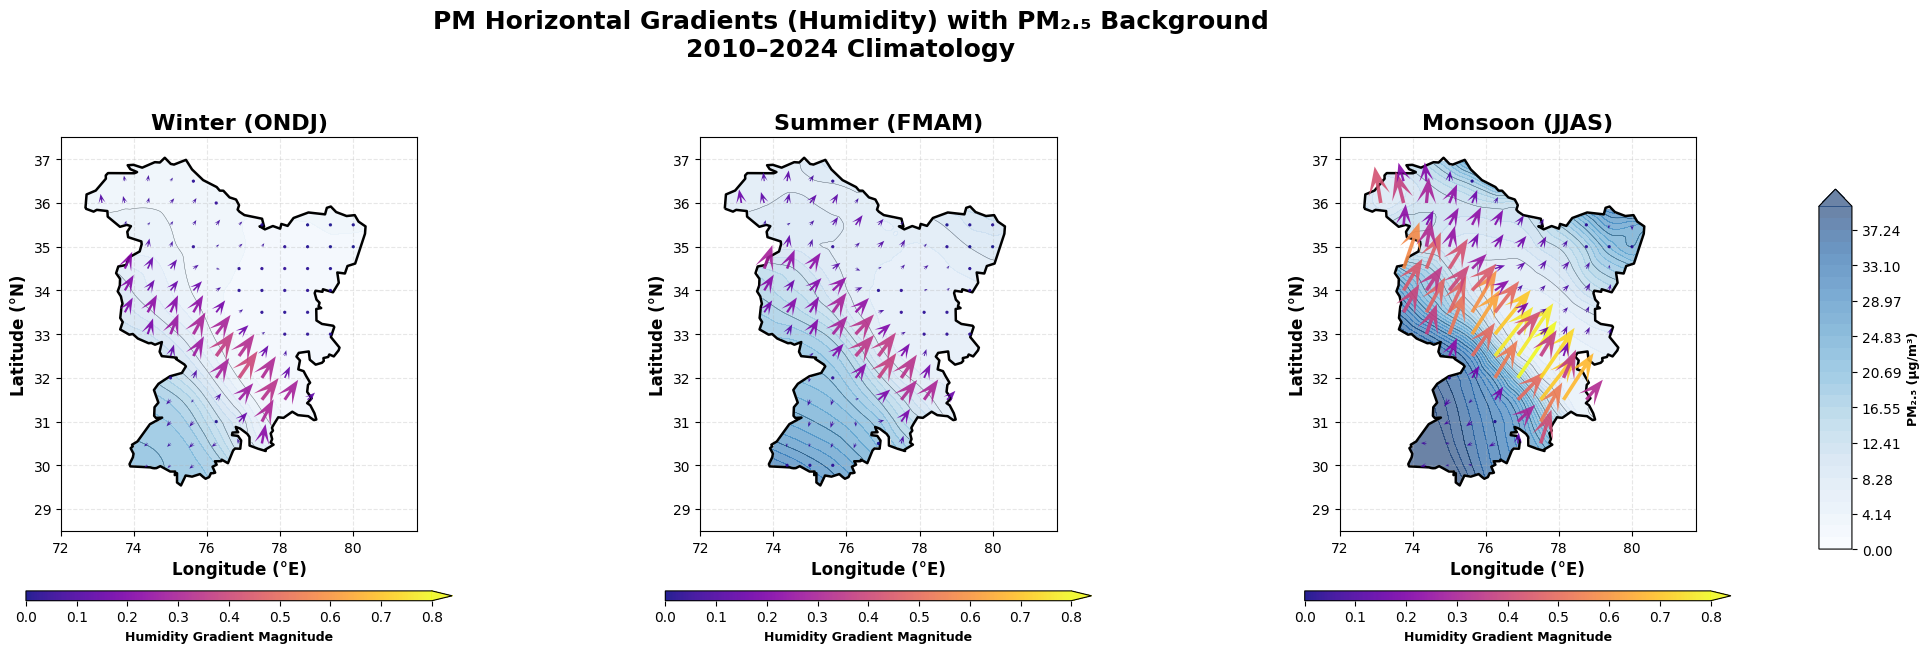

✅ Saved: /content/drive/MyDrive/NPTEL/outputs/pm25_humidity_gradient_seasonal_3panels.png


In [ ]:
SEASONS = ["Winter","Summer","Monsoon"]; S_LABS = ["ONDJ","FMAM","JJAS"]
PM25_VMAX = 40.0; HGRAD_VMAX = 0.8; ASCALE = 2.0

fig, axes = plt.subplots(1, 3, figsize=(22,9), facecolor="white",
                         gridspec_kw={"wspace":0.5,"bottom":0.22})
fig.suptitle("PM Horizontal Gradients (Humidity) with PM₂.₅ Background\n2010–2024 Climatology",
             fontsize=18, fontweight="bold", y=0.95)

pm_mappable = None
for ax, season, lab in zip(axes, SEASONS, S_LABS):
    ax.set_facecolor("white"); cs = None
    if pm25_clim is not None:
        ps = pm25_seas(pm25_clim, season)
        if ps is not None and not ps.empty:
            lns,las,vls = ps.lon.to_numpy(float),ps.lat.to_numpy(float),ps.pm25.to_numpy(float)
            gx2,gy2 = np.meshgrid(np.linspace(lns.min()-0.3,lns.max()+0.3,150),
                                   np.linspace(las.min()-0.3,las.max()+0.3,150))
            try:    gpm = griddata((lns,las),vls,(gx2,gy2),method="cubic",fill_value=np.nan)
            except: gpm = griddata((lns,las),vls,(gx2,gy2),method="linear",fill_value=np.nan)
            if nw_boundary is not None:
                try:
                    coords = np.array(list(nw_boundary.exterior.coords))
                    msk = MplPath(coords).contains_points(np.column_stack((gx2.ravel(),gy2.ravel()))).reshape(gx2.shape)
                    gpm = np.where(msk, gpm, np.nan)
                except: pass
            levels = np.linspace(0, PM25_VMAX, 30)
            cs = ax.contourf(gx2,gy2,gpm,levels=levels,cmap=plt.cm.Blues,alpha=0.6,zorder=0,extend="max")
            ax.contour(gx2,gy2,gpm,levels=levels[::3],colors="black",linewidths=0.3,alpha=0.6,zorder=1)
            pm_mappable = cs
            ax.set_xlim(lns.min()-0.5,lns.max()+0.5); ax.set_ylim(las.min()-0.5,las.max()+0.5)
    if nw_gdf is not None:
        try: nw_gdf.boundary.plot(ax=ax, color="black", linewidth=1.8, zorder=2)
        except: pass
    q = None
    if h_clim is not None:
        hs = hum_seas(h_clim, season)
        if hs is not None and not hs.empty:
            gln,glt,u,v,mag = hum_gradient(hs)
            if gln is not None:
                xs,ys,us,vs,cs2 = gln.ravel(),glt.ravel(),u.ravel()*ASCALE,v.ravel()*ASCALE,mag.ravel()
                ok = ~(np.isnan(us)|np.isnan(vs)|np.isnan(cs2))
                xs,ys,us,vs,cs2 = xs[ok],ys[ok],us[ok],vs[ok],cs2[ok]
                if nw_boundary is not None and xs.size>0:
                    try:
                        inside = MplPath(np.array(list(nw_boundary.exterior.coords))).contains_points(np.column_stack((xs,ys)))
                        xs,ys,us,vs,cs2 = xs[inside],ys[inside],us[inside],vs[inside],cs2[inside]
                    except: pass
                if xs.size>0:
                    q = ax.quiver(xs,ys,us,vs,cs2,angles="xy",scale_units="xy",scale=1.0,
                                  cmap="plasma",norm=Normalize(0,HGRAD_VMAX),
                                  width=0.010,headwidth=6,headlength=8,alpha=0.9,zorder=7)
    ax.set_title(f"{season} ({lab})",fontsize=16,fontweight="bold")
    ax.set_xlabel("Longitude (°E)",fontsize=12,fontweight="bold")
    ax.set_ylabel("Latitude (°N)",fontsize=12,fontweight="bold")
    ax.grid(True,linestyle="--",alpha=0.3); ax.tick_params(labelsize=10)
    if q is not None:
        div = make_axes_locatable(ax)
        hcax = div.append_axes("bottom",size="2.5%",pad=0.6)
        hcb = plt.colorbar(q,cax=hcax,orientation="horizontal",extend="max")
        hcb.set_label("Humidity Gradient Magnitude",fontsize=9,fontweight="bold")
if pm_mappable is not None:
    cb_ax = fig.add_axes([0.94,0.35,0.015,0.4])
    plt.colorbar(pm_mappable,cax=cb_ax,extend="max").set_label("PM₂.₅ (µg/m³)",fontsize=9,fontweight="bold")
plt.tight_layout(rect=[0,0.12,1,0.92])
out = OUTPUT_DIR/"pm25_humidity_gradient_seasonal_3panels.png"
plt.savefig(out,dpi=300,bbox_inches="tight",facecolor="white"); plt.show()
print(f" Saved: {out}")

---
##  Plot 9: Masked PM2.5 + Moran's I Triangles (Seasonal)

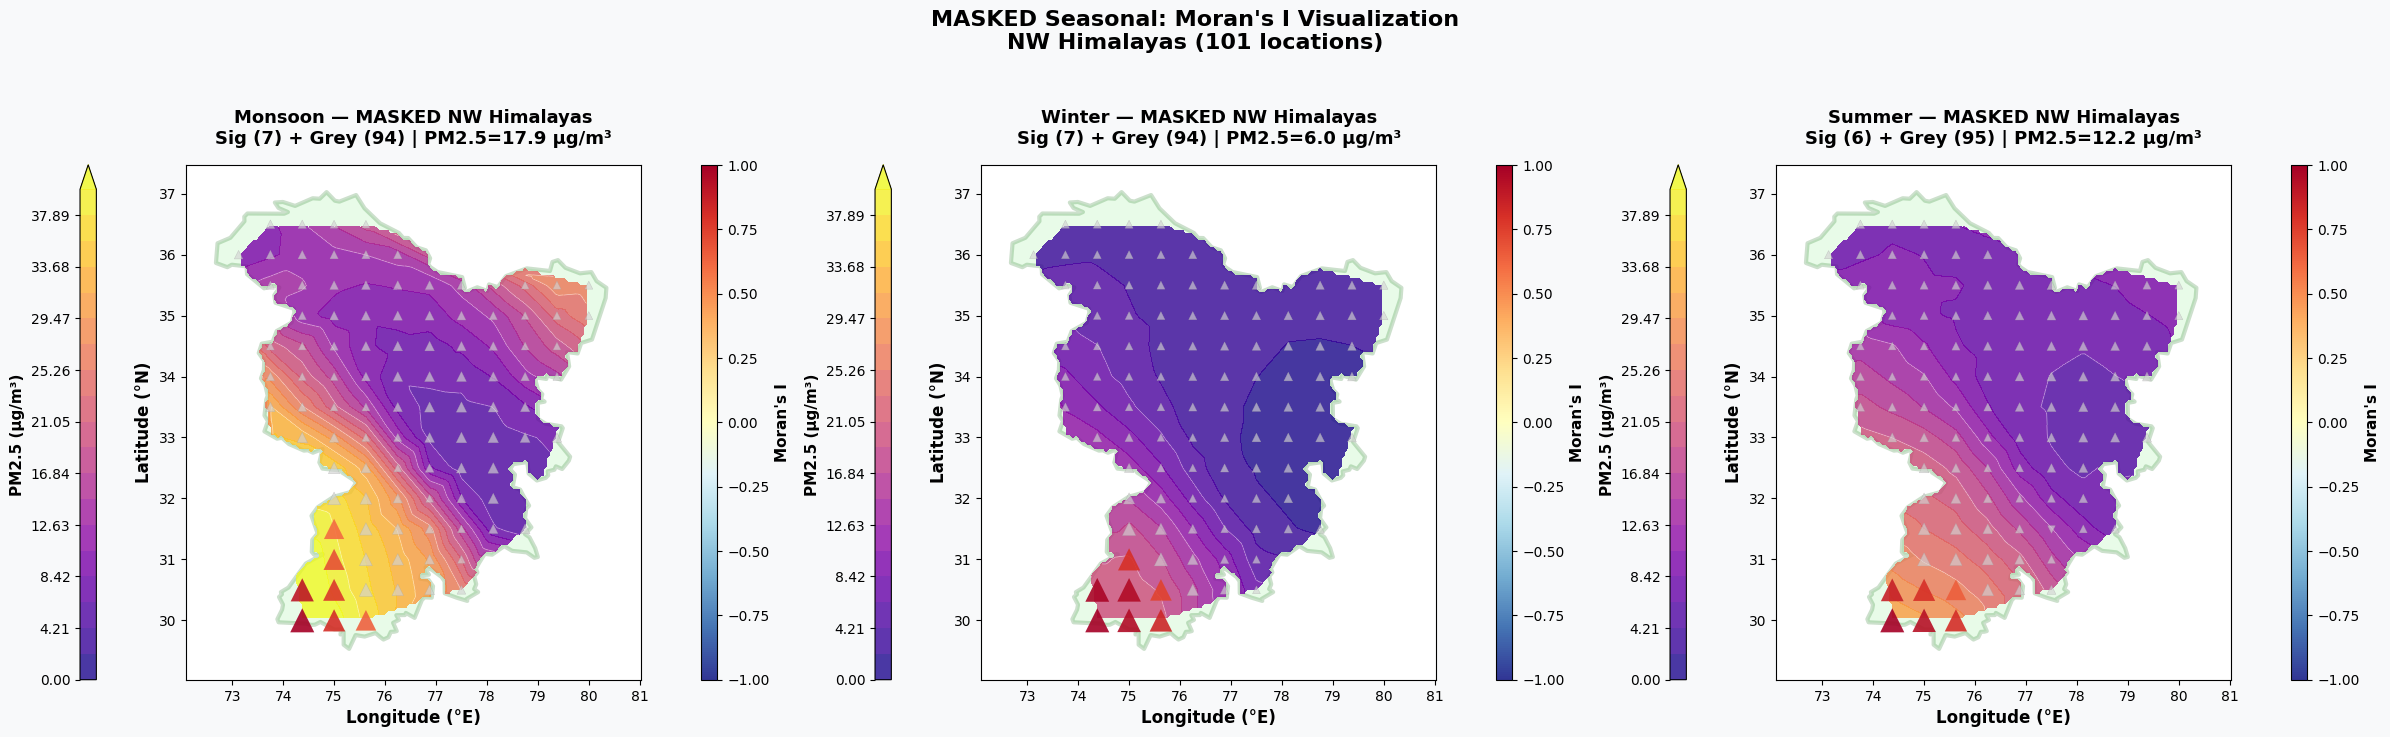

✅ Saved: /content/drive/MyDrive/NPTEL/outputs/Masked_PM25_Background_Morans_Triangles_Seasonal.png


In [ ]:
masked_df   = pd.read_csv(MASKED_PM25)
m_coords    = masked_df[["lat","lon"]].values
m_cols      = [c for c in masked_df.columns if c not in ["lat","lon"]]
lats_m, lons_m = m_coords[:,0], m_coords[:,1]
lat_pad = (lats_m.max()-lats_m.min())*0.15
lon_pad = (lons_m.max()-lons_m.min())*0.15
ext = [lons_m.min()-lon_pad, lons_m.max()+lon_pad, lats_m.min()-lat_pad, lats_m.max()+lat_pad]
lmin, lmax, latmin, latmax = ext

def pm25_bg(months):
    vals = []
    for i in range(len(masked_df)):
        lv = []
        for col in m_cols:
            try: mn = int(col.split("-")[1])
            except: continue
            if mn in months:
                v = float(masked_df.iloc[i][col])*1e9
                if not np.isnan(v): lv.append(v)
        vals.append(float(np.mean(lv)) if lv else np.nan)
    return np.array(vals, dtype=float)

def morans_i(bg):
    if not SPATIAL_STATS: return np.zeros(len(bg))
    valid = ~np.isnan(bg)
    if valid.sum() < 3: return np.zeros(len(bg))
    xy = np.column_stack([m_coords[valid,1], m_coords[valid,0]])
    k = min(8, max(1, len(xy)-1))
    try:
        w = KNN.from_array(xy, k=k); w.transform="R"
        lisa = Moran_Local(bg[valid], w, permutations=0)
        lI = lisa.Is.astype(float)
        mi = np.zeros(len(bg), dtype=float)
        mx = float(np.nanmax(np.abs(lI))) if lI.size else 0
        mi[valid] = lI/mx if mx>0 else 0
        return mi
    except: return np.zeros(len(bg))

SEAS_MAP = {"Monsoon":[6,7,8,9],"Winter":[10,11,12,1],"Summer":[2,3,4,5]}
THRESH   = 0.6

fig, axes = plt.subplots(1, 3, figsize=(24,8))
fig.patch.set_facecolor("#f8f9fa")
glat, glon = np.mgrid[latmin:latmax:150j, lmin:lmax:150j]

for idx, (sname, smonths) in enumerate(SEAS_MAP.items()):
    ax = axes[idx]; ax.set_facecolor("white")
    bg = pm25_bg(smonths); mi = morans_i(bg)
    pm_c = None
    valid = ~np.isnan(bg)
    if valid.sum() > 3:
        try:
            pg = griddata((lats_m[valid],lons_m[valid]),bg[valid],(glat,glon),method="linear")
            if nw_boundary is not None:
                gmsk = np.array([[nw_boundary.contains(Point(glon[i,j],glat[i,j]))
                                   for j in range(glon.shape[1])] for i in range(glon.shape[0])])
                pg = np.where(gmsk, pg, np.nan)
            levels = np.linspace(0,40,20)
            pm_c = ax.contourf(glon,glat,pg,levels=levels,cmap="plasma",alpha=0.8,extend="max",zorder=3)
            ax.contour(glon,glat,pg,levels=levels[::3],colors="white",linewidths=0.5,alpha=0.7,zorder=4)
        except: pass
    if nw_gdf is not None:
        try: nw_gdf.plot(ax=ax,facecolor="lightgreen",alpha=0.2,edgecolor="darkgreen",linewidth=3,zorder=2)
        except: pass
    sig = np.abs(mi) > THRESH; ns = ~sig
    sc_sig = None
    if ns.sum()>0:
        nsv = mi[ns]; nsa = np.abs(nsv)
        sz = 30+(nsa/nsa.max())*60 if nsa.max()>0 else np.full(len(nsv),30)
        for pos,mk in [(nsv>0,"^"),(nsv<0,"v")]:
            if pos.sum()>0:
                ax.scatter(lons_m[ns][pos],lats_m[ns][pos],c="lightgrey",marker=mk,
                           s=sz[pos],edgecolors="darkgrey",linewidths=0.3,alpha=0.65,zorder=8)
    if sig.sum()>0:
        sv = mi[sig]; sa = np.abs(sv)
        sz = 80+(sa/sa.max())*220 if sa.max()>0 else np.full(len(sv),80)
        for pos,mk in [(sv>0,"^"),(sv<0,"v")]:
            if pos.sum()>0:
                sc_sig = ax.scatter(lons_m[sig][pos],lats_m[sig][pos],c=sv[pos],cmap="RdYlBu_r",
                                     marker=mk,s=sz[pos],edgecolors="none",alpha=0.9,
                                     zorder=10,vmin=-1,vmax=1)
    ax.set_xlim(lmin,lmax); ax.set_ylim(latmin,latmax)
    ax.set_xlabel("Longitude (°E)",fontsize=12,fontweight="bold")
    ax.set_ylabel("Latitude (°N)",fontsize=12,fontweight="bold")
    mean_pm = float(np.nanmean(bg)) if np.isfinite(bg).any() else float("nan")
    ax.set_title(f"{sname} — MASKED NW Himalayas\nSig ({sig.sum()}) + Grey ({ns.sum()}) | PM2.5={mean_pm:.1f} µg/m³",
                 fontsize=13,fontweight="bold",pad=15)
    div = make_axes_locatable(ax)
    if pm_c is not None:
        caxl = div.append_axes("left",size="3%",pad=0.45)
        cb = plt.colorbar(pm_c,cax=caxl); cb.set_label("PM2.5 (µg/m³)",fontsize=11,fontweight="bold")
        caxl.yaxis.set_ticks_position("left"); caxl.yaxis.set_label_position("left")
    if sc_sig is not None:
        caxr = div.append_axes("right",size="3%",pad=0.15)
        sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(-1,1),cmap=plt.cm.RdYlBu_r); sm.set_array([])
        plt.colorbar(sm,cax=caxr).set_label("Moran's I",fontsize=11,fontweight="bold")

fig.suptitle(f"MASKED Seasonal: Moran's I Visualization\nNW Himalayas ({len(m_coords)} locations)",
             fontsize=16,fontweight="bold",y=0.95)
plt.tight_layout(); plt.subplots_adjust(top=0.85)
out = OUTPUT_DIR/"Masked_PM25_Background_Morans_Triangles_Seasonal.png"
plt.savefig(out,dpi=300,bbox_inches="tight",facecolor="#f8f9fa"); plt.show()
print(f" Saved: {out}")

Loading wind data...
✅ Wind speed: 6,825 monthly records, 525 locations
✅ Wind direction: 45,645 records, 255 locations
✅ Merged wind data: 689 records

Pre-monsoon: mean=2.65 m/s, max=6.62 m/s, dom dir=238.5° (WSW), n=212

Monsoon: mean=2.23 m/s, max=4.08 m/s, dom dir=247.7° (WSW), n=212

Post-monsoon: mean=-17.65 m/s, max=5.89 m/s, dom dir=231.4° (SW), n=265


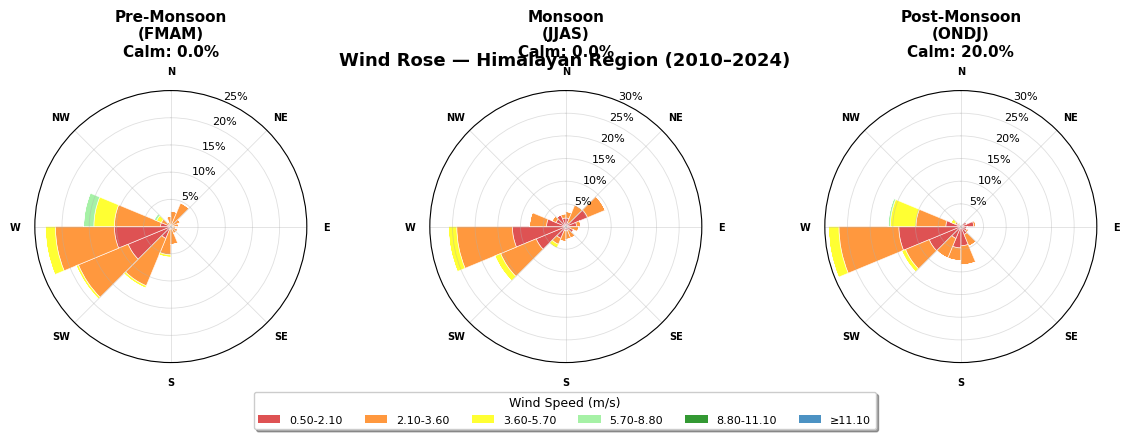


✅ Saved: /content/drive/MyDrive/NPTEL/outputs/wind_rose_seasonal.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 🌬️  Plot 11: Wind Rose — Seasonal (Pre-monsoon / Monsoon / Winter)
# ═══════════════════════════════════════════════════════════════════

import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Paths (uses DATA_DIR already set in notebook) ─────────────────
WIND_SPEED_CSV    = DATA_DIR / "wind_data.csv"       # daily rows, WS10M_LAT_LON cols
WIND_DIR_FOLDER   = DATA_DIR / "WIND_DIR"            # yearly *_wind_direction.csv files

# ── Coord parser: "2925" → 29.25, "79" → 79.0 ────────────────────
def parse_coord(part):
    val = int(part)
    return val / 100.0 if val >= 100 else float(val)

# ── Load wind SPEED from wind_data.csv (daily → monthly average) ──
def load_speed_monthly(csv_path):
    df = pd.read_csv(csv_path)
    ws_cols = [c for c in df.columns if c.startswith("WS10M_")]
    rows = []
    for _, row in df.iterrows():
        year, month = int(row["Year"]), int(row["Month"])
        for col in ws_cols:
            parts = col.split("_")[1:]
            if len(parts) < 2: continue
            try:
                rows.append({"lat": parse_coord(parts[0]),
                             "lon": parse_coord(parts[1]),
                             "year": year, "month": month,
                             "wind_speed": float(row[col])})
            except: continue
    raw = pd.DataFrame(rows)
    # Average daily → monthly per location
    monthly = raw.groupby(["lat","lon","year","month"], as_index=False)["wind_speed"].mean()
    monthly["date_str"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)
    print(f" Wind speed: {len(monthly):,} monthly records, {monthly[['lat','lon']].drop_duplicates().__len__()} locations")
    return monthly

# ── Load wind DIRECTION from WIND_DIR folder ──────────────────────
def load_direction_folder(folder):
    dfs = []
    for fp in sorted(folder.glob("20??_wind_direction.csv")):
        df = pd.read_csv(fp)
        month_cols = [c for c in df.columns if c not in ["lat","lon"]]
        df_long = pd.melt(df, id_vars=["lat","lon"], value_vars=month_cols,
                          var_name="date_str", value_name="wind_direction")
        dfs.append(df_long)
    if not dfs:
        print("  No wind direction files found"); return None
    result = pd.concat(dfs, ignore_index=True)
    result["year"]  = result["date_str"].str.split("-").str[0].astype(int)
    result["month"] = result["date_str"].str.split("-").str[1].astype(int)
    print(f" Wind direction: {len(result):,} records, {result[['lat','lon']].drop_duplicates().__len__()} locations")
    return result

# ── Merge speed + direction ───────────────────────────────────────
def build_wind_df(speed_df, dir_df):
    merged = pd.merge(speed_df, dir_df[["lat","lon","year","month","wind_direction"]],
                      on=["lat","lon","year","month"], how="inner")
    def classify(m):
        if m in [6,7,8,9]:    return "Monsoon"
        if m in [2,3,4,5]:    return "Pre-monsoon"
        return "Post-monsoon"
    merged["season"] = merged["month"].apply(classify)
    print(f" Merged wind data: {len(merged):,} records")
    return merged

# ── Wind rose helpers ─────────────────────────────────────────────
SPEED_BINS   = [0.5, 2.10, 3.60, 5.70, 8.80, 11.10, float("inf")]
SPEED_LABELS = ["0.50-2.10","2.10-3.60","3.60-5.70","5.70-8.80","8.80-11.10","≥11.10"]
SPEED_COLORS = ["#d62728","#ff7f0e","#ffff00","#90EE90","#008000","#1f77b4"]

def calc_wind_rose(speeds, directions):
    valid = (~np.isnan(speeds)) & (~np.isnan(directions))
    spd, drc = speeds[valid], directions[valid]
    if len(spd) == 0: return None, None, 0.0
    calm_pct = (spd < 0.5).sum() / len(spd) * 100
    mask = spd >= 0.5
    spd, drc = spd[mask], drc[mask]
    if len(spd) == 0: return None, None, calm_pct
    n_dir = 16
    bin_w = 360 / n_dir
    dir_centers = np.arange(bin_w/2, 360, bin_w)
    rose = np.zeros((len(SPEED_BINS)-1, n_dir))
    di = np.clip(np.digitize((drc + bin_w/2) % 360, np.arange(0,361,bin_w)) - 1, 0, n_dir-1)
    si = np.clip(np.digitize(spd, SPEED_BINS) - 1, 0, len(SPEED_BINS)-2)
    for i in range(len(spd)):
        rose[si[i], di[i]] += 1
    rose = rose / len(spd) * 100
    return rose, dir_centers, calm_pct

def plot_wind_rose(ax, speeds, directions, title):
    rose, dir_centers, calm_pct = calc_wind_rose(speeds, directions)
    if rose is None:
        ax.text(0.5, 0.5, "No Data", transform=ax.transAxes, ha="center", va="center")
        ax.set_title(title, pad=20, fontsize=11, fontweight="bold"); return
    theta = np.radians(dir_centers)
    width = np.radians(360 / len(dir_centers))
    bottom = np.zeros(len(dir_centers))
    for i, (lbl, clr) in enumerate(zip(SPEED_LABELS, SPEED_COLORS)):
        ax.bar(theta, rose[i], width=width, bottom=bottom,
               color=clr, alpha=0.8, edgecolor="white", linewidth=0.5)
        bottom += rose[i]
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.arange(0,360,45),
                      ["N","NE","E","SE","S","SW","W","NW"],
                      fontsize=7, fontweight="bold")
    max_freq = np.max(np.sum(rose, axis=0))
    r_max = max(5, np.ceil(max_freq/5)*5)
    ax.set_ylim(0, r_max)
    ticks = np.arange(0, r_max+1, 5 if r_max > 10 else 2)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{r:.0f}%" if r > 0 else "" for r in ticks], fontsize=8)
    ax.grid(True, alpha=0.4, linewidth=0.6)
    ax.set_title(f"{title}\nCalm: {calm_pct:.1f}%", pad=25, fontsize=11, fontweight="bold")

# ── Load data ─────────────────────────────────────────────────────
print("Loading wind data...")
speed_df = load_speed_monthly(WIND_SPEED_CSV)
dir_df   = load_direction_folder(WIND_DIR_FOLDER)
wind_df  = build_wind_df(speed_df, dir_df)

# ── Plot ──────────────────────────────────────────────────────────
SEASONS     = ["Pre-monsoon", "Monsoon", "Post-monsoon"]
SEA_LABELS  = ["Pre-Monsoon\n(FMAM)", "Monsoon\n(JJAS)", "Post-Monsoon\n(ONDJ)"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), subplot_kw=dict(projection="polar"))
fig.suptitle("Wind Rose — Himalayan Region (2010–2024)",
             fontsize=13, fontweight="bold", y=0.98)

for ax, season, label in zip(axes, SEASONS, SEA_LABELS):
    sdata = wind_df[wind_df["season"] == season]
    plot_wind_rose(ax, sdata["wind_speed"].values, sdata["wind_direction"].values, label)

    # Print stats
    v = sdata["wind_speed"].dropna().values
    if len(v):
        dirs = sdata["wind_direction"].dropna().values
        dom  = (np.degrees(np.arctan2(np.mean(np.sin(np.radians(dirs))),
                                       np.mean(np.cos(np.radians(dirs))))) + 360) % 360
        cdir = ["N","NNE","NE","ENE","E","ESE","SE","SSE",
                "S","SSW","SW","WSW","W","WNW","NW","NNW"]
        print(f"\n{season}: mean={v.mean():.2f} m/s, max={v.max():.2f} m/s, "
              f"dom dir={dom:.1f}° ({cdir[int((dom+11.25)/22.5)%16]}), n={len(v):,}")

# Legend
handles = [plt.Rectangle((0,0),1,1, facecolor=c, alpha=0.8) for c in SPEED_COLORS]
fig.legend(handles, SPEED_LABELS, loc="lower center", bbox_to_anchor=(0.5,0.02),
           ncol=6, title="Wind Speed (m/s)", fontsize=8, title_fontsize=9,
           frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.20, top=0.88)

out = OUTPUT_DIR / "wind_rose_seasonal.png"
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\n Saved: {out}")

Loading data...
PM2.5 records:   45,390
Wind speed recs: 6,825  (covers [np.int64(2021), np.int64(2022)])
Wind dir recs:   45,645
✅ Merged records: 689  |  years: [np.int64(2021), np.int64(2022)]
  Winter: 265 pts | PM2.5 mean=3.2 µg/m³ | WS mean=-17.65 m/s
  Summer: 212 pts | PM2.5 mean=15.9 µg/m³ | WS mean=2.65 m/s
  Monsoon: 212 pts | PM2.5 mean=16.8 µg/m³ | WS mean=2.23 m/s


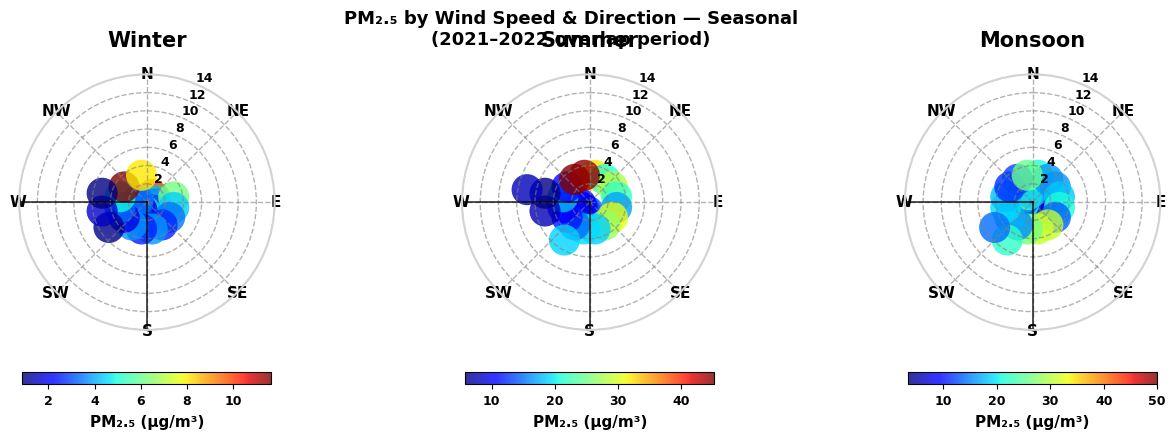

✅ Saved: /content/drive/MyDrive/NPTEL/outputs/Bipolar_WindRose_PM25_Seasonal.png


In [ ]:
# ════════════════════════════════════════════════════════════════════
#  Plot 12: Bipolar Wind Rose — PM2.5 by Wind Speed & Direction
# ════════════════════════════════════════════════════════════════════
# NOTE: Wind speed data (wind_data.csv) covers 2021-2022 only.
#       Plot uses that overlap period with PM2.5 & wind direction.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Coord parser for wind_data.csv column names ────────────────────
def parse_coord(part):
    val = int(part)
    return val / 100.0 if val >= 100 else float(val)

# ── Load wind speed from wind_data.csv → monthly avg per location ──
def load_ws_monthly(csv_path):
    df = pd.read_csv(csv_path)
    ws_cols = [c for c in df.columns if c.startswith("WS10M_")]
    rows = []
    for _, row in df.iterrows():
        year, month = int(row["Year"]), int(row["Month"])
        for col in ws_cols:
            parts = col.split("_")[1:]
            if len(parts) < 2: continue
            try:
                rows.append({"lat": parse_coord(parts[0]),
                             "lon": parse_coord(parts[1]),
                             "year": year, "month": month,
                             "wind_speed": float(row[col])})
            except: continue
    raw = pd.DataFrame(rows)
    # Daily → monthly average
    return raw.groupby(["lat","lon","year","month"], as_index=False)["wind_speed"].mean()

# ── Load wind direction from WIND_DIR folder ───────────────────────
def load_wd_folder(folder):
    dfs = []
    for fp in sorted(Path(folder).glob("20??_wind_direction.csv")):
        df = pd.read_csv(fp)
        mcols = [c for c in df.columns if c not in ["lat","lon"]]
        df_long = pd.melt(df, id_vars=["lat","lon"], value_vars=mcols,
                          var_name="date_str", value_name="wind_direction")
        df_long["year"]  = df_long["date_str"].str.split("-").str[0].astype(int)
        df_long["month"] = df_long["date_str"].str.split("-").str[1].astype(int)
        dfs.append(df_long[["lat","lon","year","month","wind_direction"]])
    return pd.concat(dfs, ignore_index=True) if dfs else None

# ── Load PM2.5 from yearly folder ─────────────────────────────────
def load_pm25_folder(folder):
    dfs = []
    for fp in sorted(Path(folder).glob("20??_data.csv")):
        df = pd.read_csv(fp)
        year = int(fp.stem.split("_")[0])
        mcols = [c for c in df.columns if c not in ["lat","lon"]]
        df_long = pd.melt(df, id_vars=["lat","lon"], value_vars=mcols,
                          var_name="date_str", value_name="pm25")
        df_long["pm25"]  = df_long["pm25"] * 1e9
        df_long["year"]  = df_long["date_str"].str.split("-").str[0].astype(int)
        df_long["month"] = df_long["date_str"].str.split("-").str[1].astype(int)
        dfs.append(df_long[["lat","lon","year","month","pm25"]])
    return pd.concat(dfs, ignore_index=True) if dfs else None

# ── Build seasonal data dict ───────────────────────────────────────
def build_seasonal(pm25_df, ws_df, wd_df):
    # Merge all three on lat/lon/year/month
    merged = pm25_df.merge(ws_df,  on=["lat","lon","year","month"], how="inner")
    merged = merged.merge(wd_df,   on=["lat","lon","year","month"], how="inner")
    merged = merged.dropna(subset=["pm25","wind_speed","wind_direction"])

    def season(m):
        if m in [10,11,12,1]: return "Winter"
        if m in [2,3,4,5]:    return "Summer"
        return "Monsoon"

    merged["season"] = merged["month"].apply(season)
    print(f" Merged records: {len(merged):,}  |  years: {sorted(merged['year'].unique())}")

    result = {}
    for s in ["Winter","Summer","Monsoon"]:
        sd = merged[merged["season"] == s]
        result[s] = {
            "pm25":           sd["pm25"].values,
            "wind_speed":     sd["wind_speed"].values,
            "wind_direction": sd["wind_direction"].values,
        }
        if len(sd):
            print(f"  {s}: {len(sd):,} pts | "
                  f"PM2.5 mean={sd['pm25'].mean():.1f} µg/m³ | "
                  f"WS mean={sd['wind_speed'].mean():.2f} m/s")
    return result

# ── Bipolar plot ───────────────────────────────────────────────────
def create_bipolar_plots(seasonal_data):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                             subplot_kw=dict(projection="polar"))
    fig.subplots_adjust(wspace=0.6, top=0.85, bottom=0.15)
    fig.suptitle("PM₂.₅ by Wind Speed & Direction — Seasonal\n(2021–2022 overlap period)",
                 fontsize=13, fontweight="bold", y=0.98)

    ws_bins = [0, 2, 4, 6, 8, 10, 12, 14]
    n_wd    = 16
    wd_edges   = np.linspace(0, 360, n_wd + 1)
    wd_centers = (wd_edges[:-1] + wd_edges[1:]) / 2
    wd_rad     = np.deg2rad(wd_centers)

    for ax, season in zip(axes, ["Winter","Summer","Monsoon"]):
        data = seasonal_data[season]
        ws, wd, pm25 = data["wind_speed"], data["wind_direction"], data["pm25"]

        if len(pm25) == 0:
            ax.text(0.5, 0.5, "No Data", transform=ax.transAxes,
                    ha="center", va="center", fontsize=11, fontweight="bold")
            ax.set_title(season, fontweight="bold", fontsize=15, pad=20)
            continue

        # Build pm25 grid [n_wd × n_ws_bins]
        pm25_grid = np.full((n_wd, len(ws_bins)-1), np.nan)
        for j, wd_c in enumerate(wd_centers):
            wd_min, wd_max = wd_edges[j], wd_edges[j+1]
            wd_mask = (wd >= wd_min) & (wd < wd_max)
            for k in range(len(ws_bins)-1):
                mask = wd_mask & (ws >= ws_bins[k]) & (ws < ws_bins[k+1])
                if mask.sum() > 0:
                    pm25_grid[j, k] = np.nanmean(pm25[mask])

        valid = pm25_grid[~np.isnan(pm25_grid)]
        vmin  = np.nanmin(valid) if len(valid) else 0
        vmax  = np.nanmax(valid) if len(valid) else 50
        if season == "Monsoon":
            vmax = min(vmax, 100) if vmax > 50 else max(vmax, 50)

        scatter = None
        for k in range(len(ws_bins)-1):
            ring = pm25_grid[:, k]
            vmask = ~np.isnan(ring)
            if vmask.sum() > 0:
                r = np.full(n_wd, (ws_bins[k] + ws_bins[k+1]) / 2)
                scatter = ax.scatter(wd_rad[vmask], r[vmask],
                                     c=ring[vmask], s=500,
                                     cmap="jet", alpha=0.8,
                                     vmin=vmin, vmax=vmax,
                                     edgecolors="none")

        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_ylim(0, 14)
        ax.tick_params(pad=-10)
        ax.set_yticks([2,4,6,8,10,12,14])
        ax.set_yticklabels([str(v) for v in [2,4,6,8,10,12,14]],
                           fontsize=9, color="black", fontweight="bold")
        ax.set_thetagrids(np.arange(0,360,45),
                          ["N","NE","E","SE","S","SW","W","NW"],
                          fontsize=11, fontweight="bold", color="black")
        ax.plot([0, np.pi],      [0,14], "k-", linewidth=1.2, alpha=0.8)
        ax.plot([np.pi/2, 3*np.pi/2], [0,14], "k-", linewidth=1.2, alpha=0.8)
        ax.grid(True, alpha=0.6, linewidth=1.0, color="gray", linestyle="--")
        ax.set_facecolor("white")
        ax.spines["polar"].set_color("lightgrey")
        ax.spines["polar"].set_linewidth(1.5)
        ax.set_title(season, fontweight="bold", fontsize=15, color="black", pad=20)

        if scatter:
            cbar = fig.colorbar(scatter, ax=ax, orientation="horizontal",
                                pad=0.12, shrink=0.9)
            cbar.ax.set_xlabel("PM₂.₅ (µg/m³)", fontsize=11,
                               fontweight="bold", labelpad=5)
            cbar.ax.tick_params(labelsize=9)
            for lbl in cbar.ax.get_xticklabels():
                lbl.set_fontweight("bold")

    return fig

# ── Run ────────────────────────────────────────────────────────────
print("Loading data...")
pm25_df = load_pm25_folder(PM25_DIR)
ws_df   = load_ws_monthly(WIND_SPEED_CSV)     # WIND_SPEED_CSV defined in Plot 10 cell
wd_df   = load_wd_folder(WIND_DIR_FOLDER)     # WIND_DIR_FOLDER defined in Plot 10 cell

print(f"PM2.5 records:   {len(pm25_df):,}")
print(f"Wind speed recs: {len(ws_df):,}  (covers {sorted(ws_df['year'].unique())})")
print(f"Wind dir recs:   {len(wd_df):,}")

seasonal_data = build_seasonal(pm25_df, ws_df, wd_df)

fig = create_bipolar_plots(seasonal_data)

out = OUTPUT_DIR / "Bipolar_WindRose_PM25_Seasonal.png"
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f" Saved: {out}")

In [ ]:
# ════════════════════════════════════════════════════════════════════
#  Plot 12: Bipolar Wind Rose — PM2.5 by Wind Speed & Direction
# ════════════════════════════════════════════════════════════════════
# NOTE: Wind speed data (wind_data.csv) covers 2021-2022 only.
#       Plot uses that overlap period with PM2.5 & wind direction.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Coord parser for wind_data.csv column names ────────────────────
def parse_coord(part):
    val = int(part)
    return val / 100.0 if val >= 100 else float(val)

# ── Load wind speed from wind_data.csv → monthly avg per location ──
def load_ws_monthly(csv_path):
    df = pd.read_csv(csv_path)
    ws_cols = [c for c in df.columns if c.startswith("WS10M_")]
    rows = []
    for _, row in df.iterrows():
        year, month = int(row["Year"]), int(row["Month"])
        for col in ws_cols:
            parts = col.split("_")[1:]
            if len(parts) < 2: continue
            try:
                rows.append({"lat": parse_coord(parts[0]),
                             "lon": parse_coord(parts[1]),
                             "year": year, "month": month,
                             "wind_speed": float(row[col])})
            except: continue
    raw = pd.DataFrame(rows)
    return raw.groupby(["lat","lon","year","month"], as_index=False)["wind_speed"].mean()

# ── Load wind direction from WIND_DIR folder ───────────────────────
def load_wd_folder(folder):
    dfs = []
    for fp in sorted(Path(folder).glob("20??_wind_direction.csv")):
        df = pd.read_csv(fp)
        mcols = [c for c in df.columns if c not in ["lat","lon"]]
        df_long = pd.melt(df, id_vars=["lat","lon"], value_vars=mcols,
                          var_name="date_str", value_name="wind_direction")
        df_long["year"]  = df_long["date_str"].str.split("-").str[0].astype(int)
        df_long["month"] = df_long["date_str"].str.split("-").str[1].astype(int)
        dfs.append(df_long[["lat","lon","year","month","wind_direction"]])
    return pd.concat(dfs, ignore_index=True) if dfs else None

# ── Load PM2.5 from yearly folder ─────────────────────────────────
def load_pm25_folder(folder):
    dfs = []
    for fp in sorted(Path(folder).glob("20??_data.csv")):
        df = pd.read_csv(fp)
        year = int(fp.stem.split("_")[0])
        mcols = [c for c in df.columns if c not in ["lat","lon"]]
        df_long = pd.melt(df, id_vars=["lat","lon"], value_vars=mcols,
                          var_name="date_str", value_name="pm25")
        df_long["pm25"]  = df_long["pm25"] * 1e9
        df_long["year"]  = df_long["date_str"].str.split("-").str[0].astype(int)
        df_long["month"] = df_long["date_str"].str.split("-").str[1].astype(int)
        dfs.append(df_long[["lat","lon","year","month","pm25"]])
    return pd.concat(dfs, ignore_index=True) if dfs else None

# ── Build seasonal data dict ───────────────────────────────────────
def build_seasonal(pm25_df, ws_df, wd_df):
    merged = pm25_df.merge(ws_df,  on=["lat","lon","year","month"], how="inner")
    merged = merged.merge(wd_df,   on=["lat","lon","year","month"], how="inner")
    merged = merged.dropna(subset=["pm25","wind_speed","wind_direction"])

    def season(m):
        if m in [10,11,12,1]: return "Winter"
        if m in [2,3,4,5]:    return "Summer"
        return "Monsoon"

    merged["season"] = merged["month"].apply(season)
    print(f" Merged records: {len(merged):,}  |  years: {sorted(merged['year'].unique())}")

    result = {}
    for s in ["Winter","Summer","Monsoon"]:
        sd = merged[merged["season"] == s]
        result[s] = {
            "pm25":           sd["pm25"].values,
            "wind_speed":     sd["wind_speed"].values,
            "wind_direction": sd["wind_direction"].values,
        }
        if len(sd):
            print(f"  {s}: {len(sd):,} pts | "
                  f"PM2.5 mean={sd['pm25'].mean():.1f} µg/m³ | "
                  f"WS mean={sd['wind_speed'].mean():.2f} m/s")
    return result

# ── Bipolar plot ───────────────────────────────────────────────────
def create_bipolar_plots(seasonal_data):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                             subplot_kw=dict(projection="polar"))
    fig.subplots_adjust(wspace=0.6, top=0.85, bottom=0.15)
    fig.suptitle("PM₂.₅ by Wind Speed & Direction — Seasonal\n(2021–2022 overlap period)",
                 fontsize=13, fontweight="bold", y=0.98)

    ws_bins = [0, 2, 4, 6, 8, 10, 12, 14]
    n_wd    = 16
    wd_edges   = np.linspace(0, 360, n_wd + 1)
    wd_centers = (wd_edges[:-1] + wd_edges[1:]) / 2
    wd_rad     = np.deg2rad(wd_centers)

    for ax, season in zip(axes, ["Winter","Summer","Monsoon"]):
        data = seasonal_data[season]
        ws, wd, pm25 = data["wind_speed"], data["wind_direction"], data["pm25"]

        if len(pm25) == 0:
            ax.text(0.5, 0.5, "No Data", transform=ax.transAxes,
                    ha="center", va="center", fontsize=11, fontweight="bold")
            ax.set_title(season, fontweight="bold", fontsize=15, pad=20)
            continue

        # Build pm25 grid [n_wd × n_ws_bins]
        pm25_grid = np.full((n_wd, len(ws_bins)-1), np.nan)
        for j, wd_c in enumerate(wd_centers):
            wd_min, wd_max = wd_edges[j], wd_edges[j+1]
            wd_mask = (wd >= wd_min) & (wd < wd_max)
            for k in range(len(ws_bins)-1):
                mask = wd_mask & (ws >= ws_bins[k]) & (ws < ws_bins[k+1])
                if mask.sum() > 0:
                    pm25_grid[j, k] = np.nanmean(pm25[mask])

        valid = pm25_grid[~np.isnan(pm25_grid)]
        vmin  = np.nanmin(valid) if len(valid) else 0
        vmax  = 50  # Fixed scale at 50 µg/m³ for all seasons

        scatter = None
        for k in range(len(ws_bins)-1):
            ring = pm25_grid[:, k]
            vmask = ~np.isnan(ring)
            if vmask.sum() > 0:
                r = np.full(n_wd, (ws_bins[k] + ws_bins[k+1]) / 2)
                scatter = ax.scatter(wd_rad[vmask], r[vmask],
                                     c=ring[vmask], s=500,
                                     cmap="jet", alpha=0.8,
                                     vmin=vmin, vmax=vmax,
                                     edgecolors="none")

        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_ylim(0, 14)
        ax.tick_params(pad=-10)
        ax.set_yticks([2,4,6,8,10,12,14])
        ax.set_yticklabels([str(v) for v in [2,4,6,8,10,12,14]],
                           fontsize=9, color="black", fontweight="bold")
        ax.set_thetagrids(np.arange(0,360,45),
                          ["N","NE","E","SE","S","SW","W","NW"],
                          fontsize=11, fontweight="bold", color="black")
        ax.plot([0, np.pi],      [0,14], "k-", linewidth=1.2, alpha=0.8)
        ax.plot([np.pi/2, 3*np.pi/2], [0,14], "k-", linewidth=1.2, alpha=0.8)
        ax.grid(True, alpha=0.6, linewidth=1.0, color="gray", linestyle="--")
        ax.set_facecolor("white")
        ax.spines["polar"].set_color("lightgrey")
        ax.spines["polar"].set_linewidth(1.5)
        ax.set_title(season, fontweight="bold", fontsize=15, color="black", pad=20)

        if scatter:
            cbar = fig.colorbar(scatter, ax=ax, orientation="horizontal",
                                pad=0.12, shrink=0.9)
            cbar.ax.set_xlabel("PM₂.₅ (µg/m³)", fontsize=11,
                               fontweight="bold", labelpad=5)
            cbar.ax.tick_params(labelsize=9)
            for lbl in cbar.ax.get_xticklabels():
                lbl.set_fontweight("bold")

    return fig

# ── Run ────────────────────────────────────────────────────────────
print("Loading data...")
pm25_df = load_pm25_folder(PM25_DIR)
ws_df   = load_ws_monthly(WIND_SPEED_CSV)
wd_df   = load_wd_folder(WIND_DIR_FOLDER)

print(f"PM2.5 records:   {len(pm25_df):,}")
print(f"Wind speed recs: {len(ws_df):,}  (covers {sorted(ws_df['year'].unique())})")
print(f"Wind dir recs:   {len(wd_df):,}")

seasonal_data = build_seasonal(pm25_df, ws_df, wd_df)

fig = create_bipolar_plots(seasonal_data)

out = OUTPUT_DIR / "Bipolar_WindRose_PM25_Seasonal.png"
plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f" Saved: {out}")

Loading data...


NameError: name 'WIND_SPEED_CSV' is not defined